# Motor de Herança Estrutural — Varredura via Órbita de σ
**Paper 08 — Tiago Bandeira**

Notebook atualizado: substitui a heurística anterior pela busca fiel ao Motor de Herança.
A função `orbitar_sigma_hr_menos` implementa os deslocamentos simétricos
$e_1(t) = e_1(0) + 2t$, $e_3(t) = e_3(0) - 2t$ da Observação 2.5,
garantindo $e_1(t) + e_3(t) = 2M^-$ constante em toda a órbita.

---
## ⚙️ Parâmetros — edite aqui antes de rodar

In [45]:
# ============================================================
# PARÂMETROS — edite aqui
# ============================================================

# Motor de Herança — HR⁻ via órbita de sigma
M_MAX_MOTOR   = 500          # simula o motor de 2M=6 até 2*M_MAX_MOTOR
SALVAR_MOTOR  = True

# Frente 4
M_MAX   = 50_000
DELTAS  = [0.3, 0.4, 0.5, 0.6, 0.7]
PASSO_M = 2

# Frente 2 — análise espectral pontual
N_PONTUAL = 500

# Frente 2 — varredura de N
# Inclui valores grandes para observar regime assintótico da Prop. 5.2
NS_VARREDURA = [101, 200, 1001, 2000, 10001, 20000]#[100, 500, 1000, 2000, 5000, 10000, 50000]

# Controle de execução
RODAR_MOTOR   = True
RODAR_FRENTE4 = True
RODAR_FRENTE2 = True
SALVAR_GRAFICOS = True


In [46]:
# ============================================================
# INSTALAÇÃO (Colab já tem numpy/matplotlib; sympy também)
# ============================================================
# Se der ImportError, descomente:
# !pip install numpy scipy sympy matplotlib pandas -q


In [47]:
# ============================================================
# IMPORTS E UTILITÁRIOS BASE
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

def crivo_eratostenes(limite: int) -> np.ndarray:
    """Array booleano is_prime[n] para n em [0, limite]."""
    is_prime = np.ones(limite + 1, dtype=bool)
    is_prime[0] = is_prime[1] = False
    for i in range(2, int(limite**0.5) + 1):
        if is_prime[i]:
            is_prime[i*i::i] = False
    return is_prime

def von_mangoldt_array(limite: int) -> np.ndarray:
    """Vetor Λ(n) para n em [0, limite]."""
    Lambda = np.zeros(limite + 1, dtype=float)
    is_prime = crivo_eratostenes(limite)
    primes = np.where(is_prime)[0]
    Lambda[primes] = np.log(primes.astype(float))
    for p in primes:
        pk = p * p
        while pk <= limite:
            Lambda[pk] = np.log(float(p))
            pk *= p
    return Lambda

def linhas_mediana(N: int):
    """
    Retorna (e1, e3, K) conforme Observação 2.5 do Paper 08.
    e1(t) = 1 + 2t,  e3(t) = (2N-3) - 2t,  t = 1..K, K = N-1.
    """
    K = N - 1
    t = np.arange(1, K + 1, dtype=int)
    e1 = 1 + 2 * t
    e3 = (2*N - 3) - 2 * t
    return e1, e3, K

print('✓ Utilitários base carregados.')


✓ Utilitários base carregados.


---
## 🔧 Motor de Herança Estrutural — HR⁻ via Órbita de σ

Esta seção implementa o mecanismo real descrito no Paper 05/08:

1. **Herança:** o par certificado em $2M$ ancora o estado inicial de $2M+2$.
2. **Órbita de σ:** deslocamentos $e_1(t)=e_1(0)+2t$, $e_3(t)=e_3(0)-2t$ mantêm
   $e_1+e_3=2M^-$ constante (Obs. 2.5).
3. **Colisão prima:** busca o menor $t$ tal que $e_1(t) \in \mathbb{P}$ e $e_3(t) \in \mathbb{P}$.
4. **Métrica $t_\sigma$:** registra o "esforço" da busca — se $t=0$, a herança
   já entrega um par primo imediato; quanto maior $t$, mais a órbita precisou varrer.

MOTOR DE HERANÇA ESTRUTURAL
Gerando crivo até 1,010...
Motor de Herança: 2M = 6 → 1000
      2M      p1      p3    t_σ      modo  estado
-------------------------------------------------------
       6       3       3      0      base  ✓
       8       3       5      0   herdado  ✓
      10       3       7      0   herdado  ✓
      12       5       7      0         A  ✓
      14       7       7      0         A  ✓
      16       5      11      1         B  ✓
      18       5      13      0   herdado  ✓
      20       7      13      1         B  ✓
      22      11      11      0         A  ✓
      24      11      13      0   herdado  ✓
      26      13      13      0         A  ✓
      28      11      17      1         B  ✓
      30      11      19      0   herdado  ✓
      32      13      19      1         B  ✓
      34      17      17      0         A  ✓
      36      17      19      0   herdado  ✓
      38      19      19      0         A  ✓
      40      17      23      1         B 

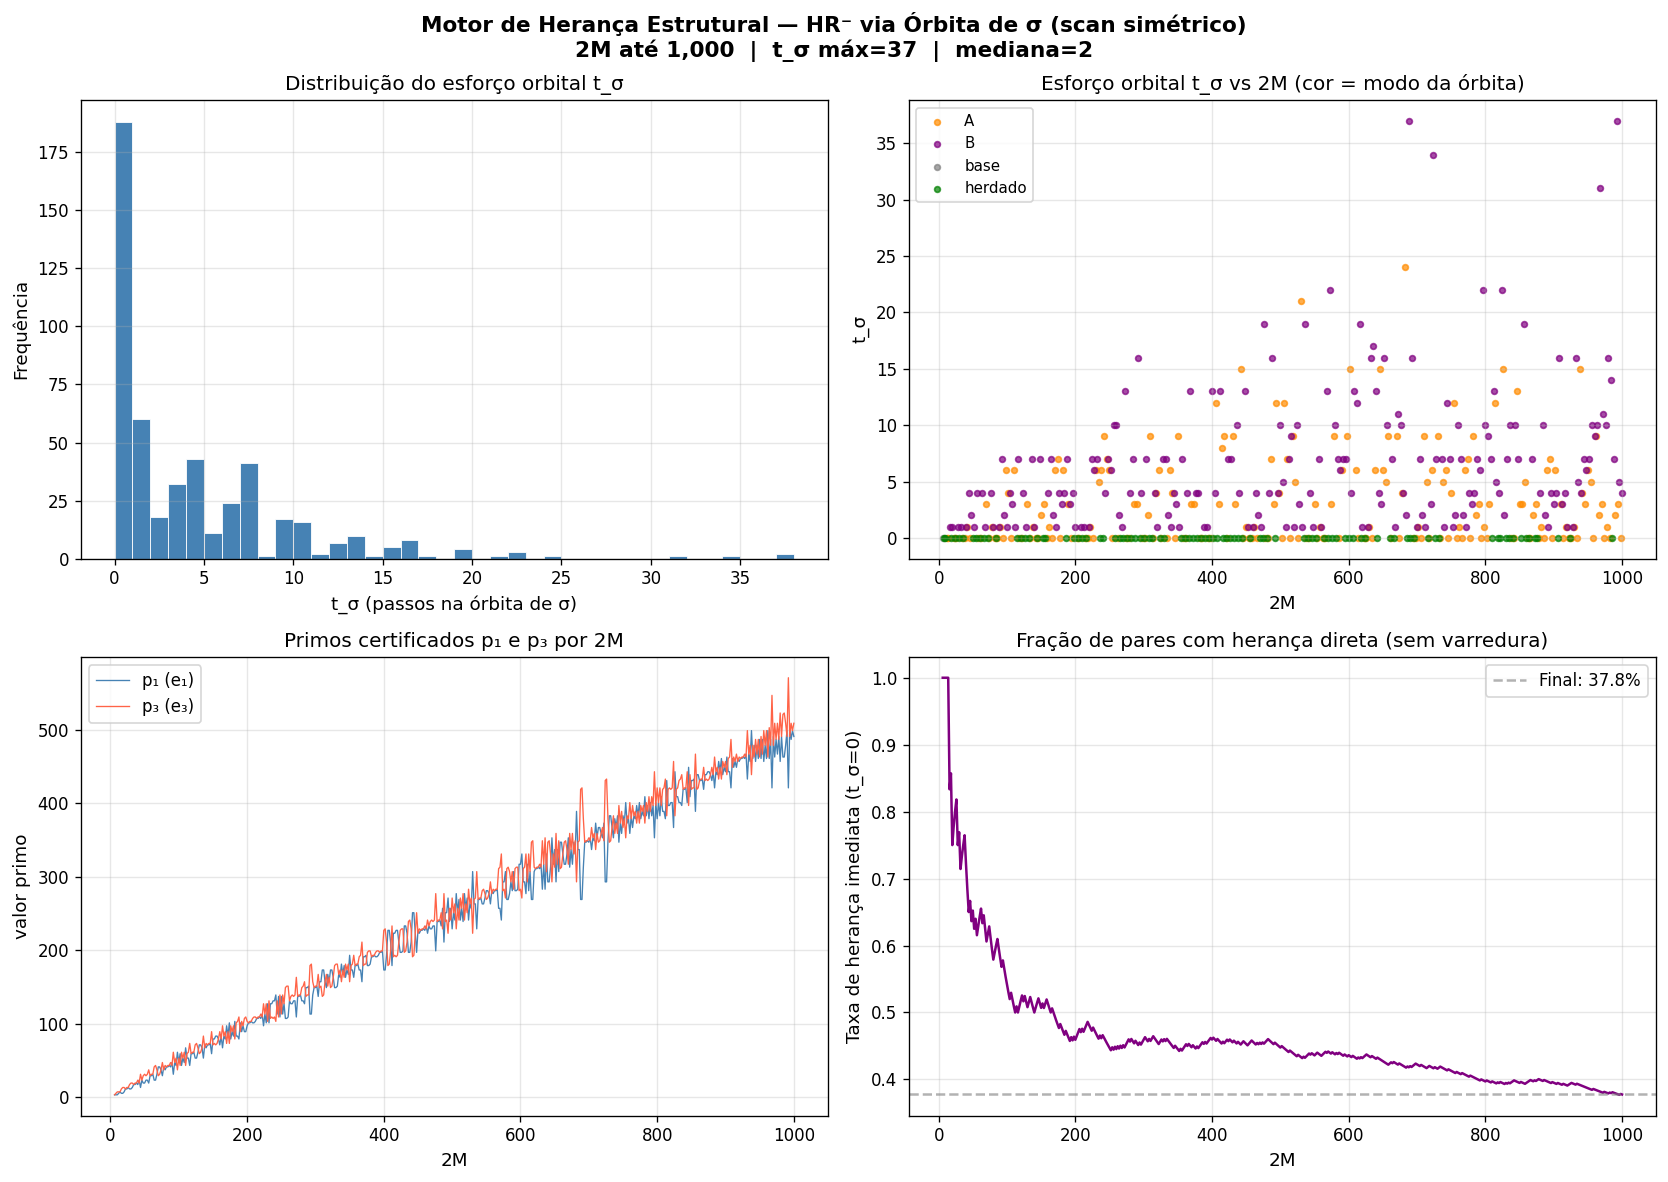


--- Estatísticas do esforço orbital t_σ ---
count    498.000000
mean       3.949799
std        5.474239
min        0.000000
25%        0.000000
50%        2.000000
75%        6.000000
max       37.000000

Pares com herança imediata (t_σ=0): 188 / 498 (37.8%)


In [48]:
# ============================================================
# MOTOR DE HERANÇA ESTRUTURAL — implementação fiel à Obs. 2.5
# ============================================================

def orbitar_sigma_hr_menos(soma_alvo: int, is_prime: np.ndarray, e1_hint: int = None):
    """
    Busca na órbita de σ um par primo (e1, e3) com e1 + e3 = soma_alvo.

    Estratégia de ancoragem (fita-dobra, Prop. 3.6):
      - Ponto médio simétrico: e1_mid = soma_alvo // 2  (ímpar mais próximo)
      - Desloca bidirecionalmente: t = 0, 1, 2, ...
          Sentido A (e1 sobe): e1 = e1_mid + 2t,  e3 = e1_mid_par - 2t
          Sentido B (e1 desce): e1 = e1_mid - 2t,  e3 = e1_mid_par + 2t
      - Garante e1 + e3 = soma_alvo em todo t.

    Quando e1_hint é fornecido (herança), testa primeiro a posição herdada
    antes de cair no scan simétrico — economizando varredura quando a
    herança já entrega um par primo diretamente.

    Equações de movimento (Obs. 2.5):
        e1(t) + e3(t) = soma_alvo = 2M  (constante)

    Retorna:
        (e1, e3, t, modo) se encontrado, ou (None, None, -1, None).
    """
    limite = len(is_prime) - 1

    # ── 0. Teste de herança direta (t=0 no ponto herdado)
    if e1_hint is not None:
        e3_hint = soma_alvo - e1_hint
        if (3 <= e1_hint <= limite and 3 <= e3_hint <= limite
                and is_prime[e1_hint] and is_prime[e3_hint]):
            return e1_hint, e3_hint, 0, 'herdado'

    # ── 1. Scan simétrico a partir do ponto médio
    # Ponto médio: maior ímpar <= soma_alvo // 2
    mid = soma_alvo // 2
    if mid % 2 == 0:
        mid -= 1          # garante ímpar
    e1_mid = mid
    e3_mid = soma_alvo - e1_mid    # também ímpar (soma de dois ímpares = par)

    t = 0
    while True:
        # Sentido A: e1 cresce a partir do meio
        e1_A = e1_mid + 2 * t
        e3_A = soma_alvo - e1_A
        # Sentido B: e1 decresce a partir do meio
        e1_B = e1_mid - 2 * t
        e3_B = soma_alvo - e1_B

        dentro_A = 3 <= e1_A <= limite and 3 <= e3_A <= limite
        dentro_B = 3 <= e1_B <= limite and 3 <= e3_B <= limite

        if not dentro_A and not dentro_B:
            break    # órbita completamente esgotada

        if dentro_A and is_prime[e1_A] and is_prime[e3_A]:
            return e1_A, e3_A, t, 'A'
        if dentro_B and t > 0 and is_prime[e1_B] and is_prime[e3_B]:
            return e1_B, e3_B, t, 'B'

        t += 1

    return None, None, -1, None    # HR⁻ falhou (teoricamente impossível)


def simular_motor_heranca(M_max: int, is_prime: np.ndarray):
    """
    Roda o Motor de Herança de 2M=6 até 2*M_max.

    Herança estrutural (Prop. 3.6 + Obs. 2.5):
      Para cada promoção 2M → 2M+2, passa e1_hint = p1 do par certificado
      anterior. O motor testa primeiro essa posição herdada (t=0); se falhar,
      faz o scan simétrico completo a partir do ponto médio de 2M+2.
      Em ambos os casos e1 + e3 = 2M+2 é mantido constante.
    """
    print(f"Motor de Herança: 2M = 6 → {2*M_max}")
    print(f"{'2M':>8}  {'p1':>6}  {'p3':>6}  {'t_σ':>5}  {'modo':>8}  estado")
    print("-" * 55)

    registros = []

    # Estado inicial: 2M=6 → (3,3)
    p1, p3   = 3, 3
    soma_atual = 6
    t_sigma    = 0
    modo       = 'base'

    while soma_atual <= 2 * M_max:
        print(f"{soma_atual:>8}  {p1:>6}  {p3:>6}  {t_sigma:>5}  {modo:>8}  ✓")
        registros.append({'2M': soma_atual, 'p1': p1, 'p3': p3,
                          't_sigma': t_sigma, 'modo': modo})

        # ── PROMOÇÃO
        soma_alvo = soma_atual + 2

        # ── HERANÇA: testa p1 herdado primeiro, depois scan simétrico
        novo_p1, novo_p3, t_sigma, modo = orbitar_sigma_hr_menos(
            soma_alvo, is_prime, e1_hint=p1
        )

        if novo_p1 is None:
            print(f"ALERTA: HR⁻ falhou em 2M = {soma_alvo}!")
            break

        p1, p3     = novo_p1, novo_p3
        soma_atual = soma_alvo

    df = pd.DataFrame(registros)
    print(f"\n✓ Cadeia ininterrupta: {len(df)} pares certificados.")
    return df


def plotar_motor(df: pd.DataFrame):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Painel 1 — distribuição de t_sigma
    ax = axes[0, 0]
    ax.hist(df['t_sigma'], bins=range(0, df['t_sigma'].max() + 2),
            color='steelblue', edgecolor='white', linewidth=0.5)
    ax.set_xlabel('t_σ (passos na órbita de σ)', fontsize=11)
    ax.set_ylabel('Frequência', fontsize=11)
    ax.set_title('Distribuição do esforço orbital t_σ', fontsize=12)
    ax.grid(True, alpha=0.3)

    # Painel 2 — t_sigma ao longo de 2M, colorido por modo
    ax2 = axes[0, 1]
    cores = {'herdado': 'green', 'A': 'darkorange', 'B': 'purple', 'base': 'gray'}
    for modo, grp in df.groupby('modo'):
        ax2.scatter(grp['2M'], grp['t_sigma'], s=12, alpha=0.7,
                    color=cores.get(modo, 'black'), label=modo)
    ax2.set_xlabel('2M', fontsize=11)
    ax2.set_ylabel('t_σ', fontsize=11)
    ax2.set_title('Esforço orbital t_σ vs 2M (cor = modo da órbita)', fontsize=12)
    ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

    # Painel 3 — p1 e p3 ao longo de 2M
    ax3 = axes[1, 0]
    ax3.plot(df['2M'], df['p1'], lw=0.8, label='p₁ (e₁)', color='steelblue')
    ax3.plot(df['2M'], df['p3'], lw=0.8, label='p₃ (e₃)', color='tomato')
    ax3.set_xlabel('2M', fontsize=11)
    ax3.set_ylabel('valor primo', fontsize=11)
    ax3.set_title('Primos certificados p₁ e p₃ por 2M', fontsize=12)
    ax3.legend(); ax3.grid(True, alpha=0.3)

    # Painel 4 — taxa acumulada de herança imediata (t_sigma == 0)
    ax4 = axes[1, 1]
    taxa_imediata = (df['t_sigma'] == 0).cumsum() / (np.arange(len(df)) + 1)
    ax4.plot(df['2M'], taxa_imediata, color='purple', lw=1.5)
    ax4.axhline(taxa_imediata.iloc[-1], color='gray', ls='--', alpha=0.6,
                label=f"Final: {taxa_imediata.iloc[-1]:.1%}")
    ax4.set_xlabel('2M', fontsize=11)
    ax4.set_ylabel('Taxa de herança imediata (t_σ=0)', fontsize=11)
    ax4.set_title('Fração de pares com herança direta (sem varredura)', fontsize=12)
    ax4.legend(); ax4.grid(True, alpha=0.3)

    fig.suptitle(
        f'Motor de Herança Estrutural — HR⁻ via Órbita de σ (scan simétrico)\n'
        f'2M até {df["2M"].max():,}  |  '
        f't_σ máx={df["t_sigma"].max()}  |  '
        f'mediana={df["t_sigma"].median():.0f}',
        fontsize=13, fontweight='bold')
    plt.tight_layout()
    if SALVAR_GRAFICOS:
        plt.savefig('motor_heranca_sigma.png', dpi=150)
        print('Salvo: motor_heranca_sigma.png')
    plt.show()


if RODAR_MOTOR:
    print('=' * 60)
    print('MOTOR DE HERANÇA ESTRUTURAL')
    print('=' * 60)
    limite_motor = 2 * M_MAX_MOTOR + 10
    print(f'Gerando crivo até {limite_motor:,}...')
    is_prime_motor = crivo_eratostenes(limite_motor)

    df_motor = simular_motor_heranca(M_MAX_MOTOR, is_prime_motor)
    plotar_motor(df_motor)

    print('\n--- Estatísticas do esforço orbital t_σ ---')
    print(df_motor['t_sigma'].describe().to_string())
    print(f"\nPares com herança imediata (t_σ=0): "          f"{(df_motor['t_sigma']==0).sum()} / {len(df_motor)} "          f"({(df_motor['t_sigma']==0).mean():.1%})")


---
## Frente 4 — Varredura de δ: L = M^δ

Verifica HR⁻ usando a janela de busca polinomial $L = M^\delta$ em vez da heurística clássica $(\log M)^2$.
O mecanismo interno **usa a órbita de σ** para cada $M$.

FRENTE 4 — Varredura de delta (órbita de σ)
Gerando crivo até 100,010…
Crivo pronto em 0.0s

δ=0.30  |  19196/25000 (76.8%)  |  Falhas iniciais: [4, 12, 24, 28, 36, 48, 52, 60]  [0.1s]
δ=0.40  |  23754/25000 (95.0%)  |  Falhas iniciais: [4, 12, 24, 28, 36, 48, 52, 60]  [0.1s]
δ=0.50  |  24895/25000 (99.6%)  |  Falhas iniciais: [4, 12, 24, 28, 36, 48, 60, 68]  [0.1s]
δ=0.60  |  24987/25000 (99.9%)  |  Falhas iniciais: [4, 12, 24, 28, 128, 220, 308, 488]  [0.1s]
δ=0.70  |  24997/25000 (100.0%)  |  Falhas iniciais: [4, 12, 128]  [0.1s]
Salvo: frente4_delta.png


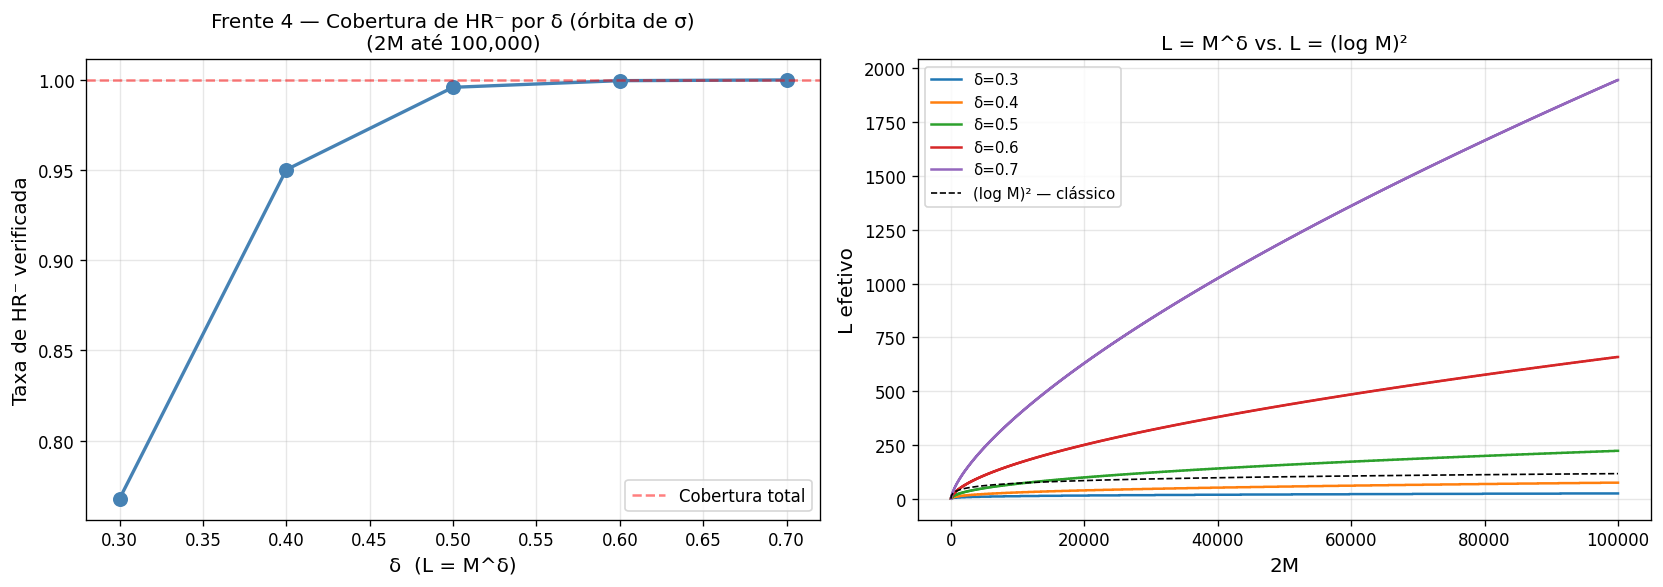

In [49]:
# ============================================================
# FRENTE 4 — HR⁻ via órbita de σ com janela L = M^delta
# ============================================================

def hr_menos_sigma(M: int, L: int, is_prime: np.ndarray):
    """
    Verifica HR⁻ para 2M usando a órbita de σ restrita à janela [3, L].

    Ancora o estado inicial em e1_base=3, e3_base=2M-3
    (primeiro ímpar ≥ 3 à esquerda), e desliza até e1 <= L.

    Retorna (ok: bool, t_encontrado: int).
    """
    limite = len(is_prime) - 1
    e1_base = 3
    e3_base = 2 * M - 3       # e1+e3 = 2M (constante)
    t = 0

    while True:
        e1 = e1_base + 2 * t
        e3 = e3_base - 2 * t

        if e1 > L or e3 < 3:
            break             # saiu da janela sem colisão

        if e1 <= limite and e3 <= limite:
            if is_prime[e1] and is_prime[e3]:
                return True, t
        t += 1

    return False, -1


def frente4_varredura_delta(M_max, deltas, passo=2):
    t0 = time.time()
    limite_crivo = 2 * M_max + 10
    print(f'Gerando crivo até {limite_crivo:,}…')
    is_prime = crivo_eratostenes(limite_crivo)
    print(f'Crivo pronto em {time.time()-t0:.1f}s\n')

    resultados = {}
    for delta in deltas:
        t1 = time.time()
        serie, falhas = [], []
        for M in range(2, M_max + 1, passo):
            L = max(3, int(M ** delta))
            ok, _ = hr_menos_sigma(M, L, is_prime)
            serie.append((2*M, L, ok))
            if not ok:
                falhas.append(2*M)
        resultados[delta] = serie
        n_total = len(serie)
        n_ok    = sum(1 for _, _, ok in serie if ok)
        print(f'δ={delta:.2f}  |  {n_ok}/{n_total} ({100*n_ok/n_total:.1f}%)  |  '
              f'Falhas iniciais: {falhas[:8] if falhas else "nenhuma"}  '
              f'[{time.time()-t1:.1f}s]')
    return resultados


def plotar_frente4(resultados, M_max):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    deltas_sorted = sorted(resultados.keys())
    taxas = [sum(1 for _,_,ok in resultados[d] if ok)/len(resultados[d])
             for d in deltas_sorted]
    ax.plot(deltas_sorted, taxas, 'o-', color='steelblue', lw=2, ms=8)
    ax.axhline(1.0, color='red', ls='--', alpha=0.5, label='Cobertura total')
    ax.set_xlabel('δ  (L = M^δ)', fontsize=12)
    ax.set_ylabel('Taxa de HR⁻ verificada', fontsize=12)
    ax.set_title(f'Frente 4 — Cobertura de HR⁻ por δ (órbita de σ)\n'
                 f'(2M até {2*M_max:,})', fontsize=12)
    ax.legend(); ax.grid(True, alpha=0.3)

    ax2 = axes[1]
    Ms = np.arange(2, M_max + 1, 2)
    for delta in deltas_sorted:
        ax2.plot(2*Ms, np.floor(Ms**delta), label=f'δ={delta}', lw=1.5)
    ax2.plot(2*Ms, np.log(Ms)**2, 'k--', label='(log M)² — clássico', lw=1)
    ax2.set_xlabel('2M', fontsize=12)
    ax2.set_ylabel('L efetivo', fontsize=12)
    ax2.set_title('L = M^δ vs. L = (log M)²', fontsize=12)
    ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    if SALVAR_GRAFICOS:
        plt.savefig('frente4_delta.png', dpi=150)
        print('Salvo: frente4_delta.png')
    plt.show()


if RODAR_FRENTE4:
    print('=' * 60)
    print('FRENTE 4 — Varredura de delta (órbita de σ)')
    print('=' * 60)
    res4 = frente4_varredura_delta(M_MAX, DELTAS, PASSO_M)
    plotar_frente4(res4, M_MAX)


---
## Frente 2 — Análise espectral de ŵ(j)

A função de peso $w(t) = \Lambda(e_1(t))\cdot\Lambda(e_3(t))$ é calculada
**diretamente sobre a órbita de σ** (Obs. 2.5), e não sobre combinações aleatórias.
O esforço orbital $t_\sigma$ pode ser usado como sinal base para a FFT.

FRENTE 2 — Análise espectral de ŵ(j)
N=500, K=499,  2M⁻ = 998
  ŵ(0)               = 2.661916
  max|ŵ(j≠0)|        = 2.178108
  mean|ŵ(j≠0)|       = 0.304002
  ŵ(0)/mean|ŵ(j≠0)| = 8.76×
  HR⁻ verificada:      ✓ sim  [ŵ(0)>0]
Salvo: frente2_espectro_N500.png


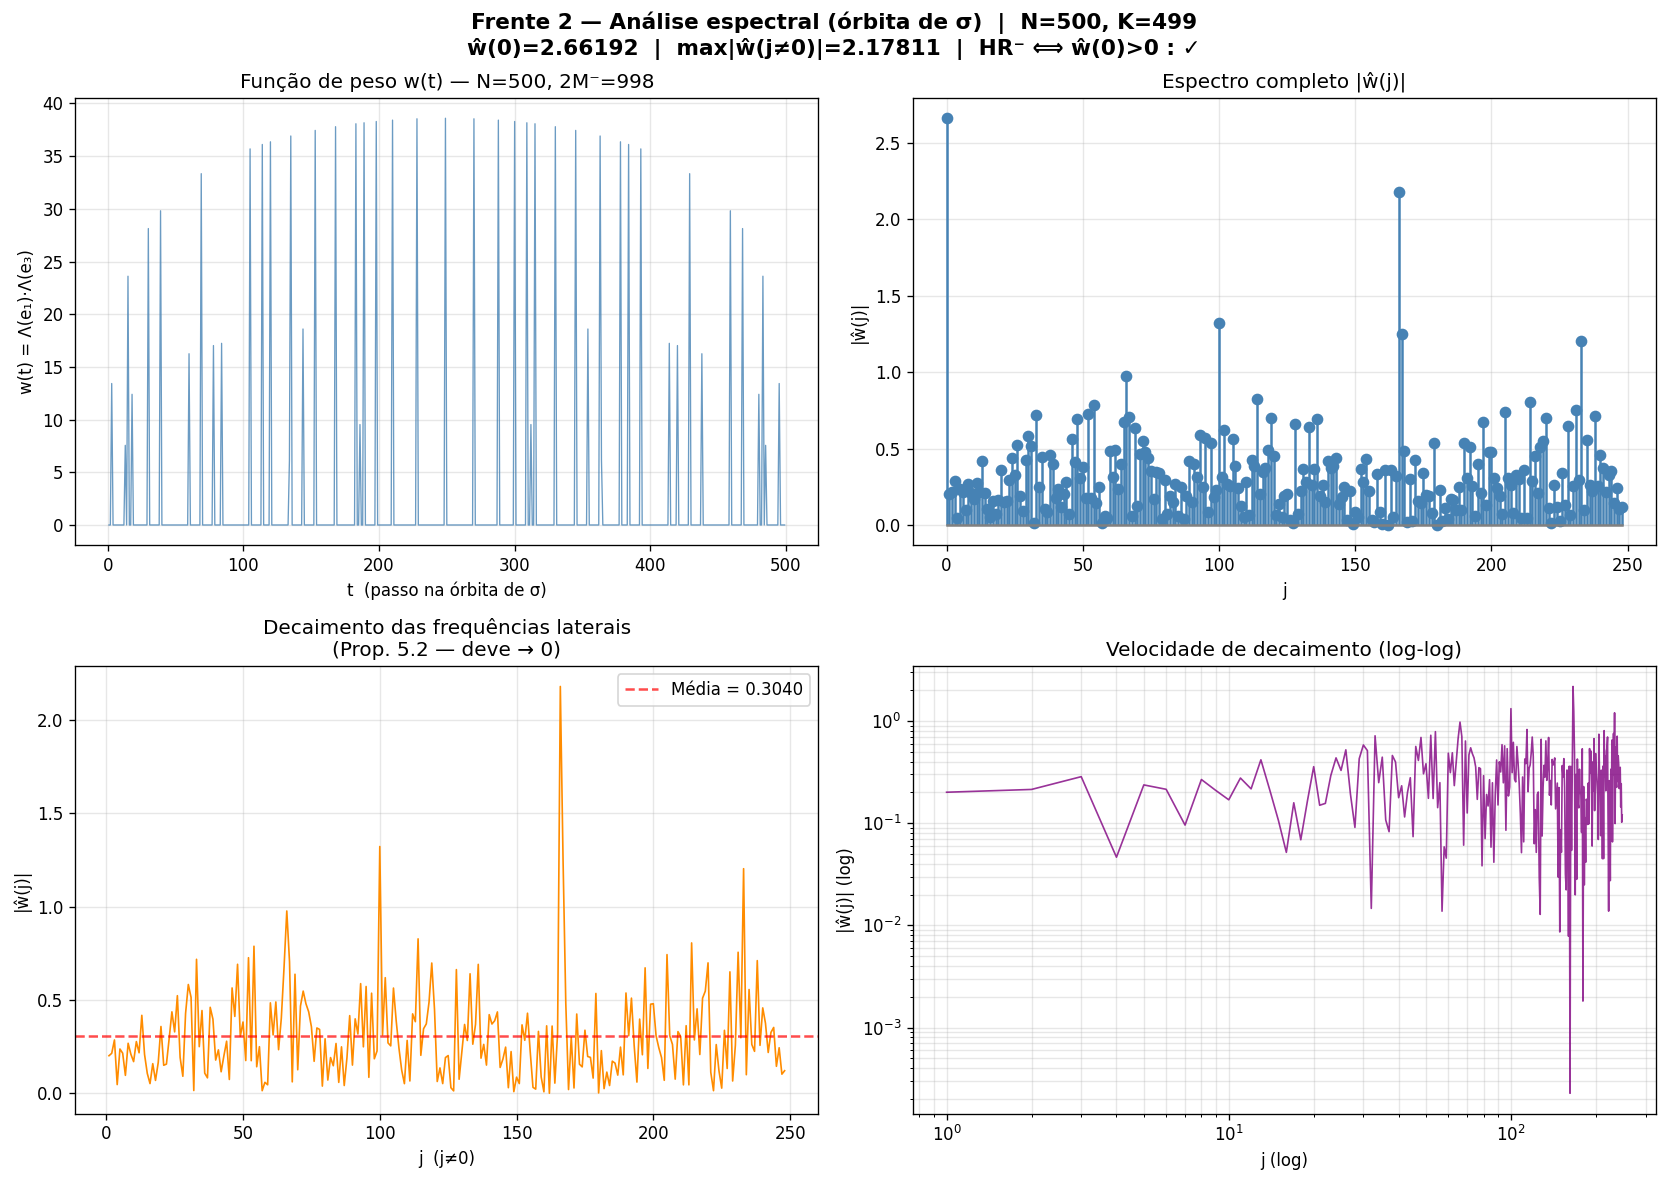


Varredura de N:

     N       K       2M⁻          ŵ(0)       max|ŵ(j≠0)|     razão  HR⁻
----------------------------------------------------------------------
   101     100       200      3.430278          2.283229      1.50×  ✓
   200     199       398      2.413188          1.733273      1.39×  ✓
  1001    1000      2000      3.422993          2.823332      1.21×  ✓
  2000    1999      3998      2.687204          2.206231      1.22×  ✓
 10001   10000     20000      3.653987          3.016721      1.21×  ✓
 20000   19999     39998      3.031095          2.508849      1.21×  ✓
Salvo: frente2_varredura_N.png


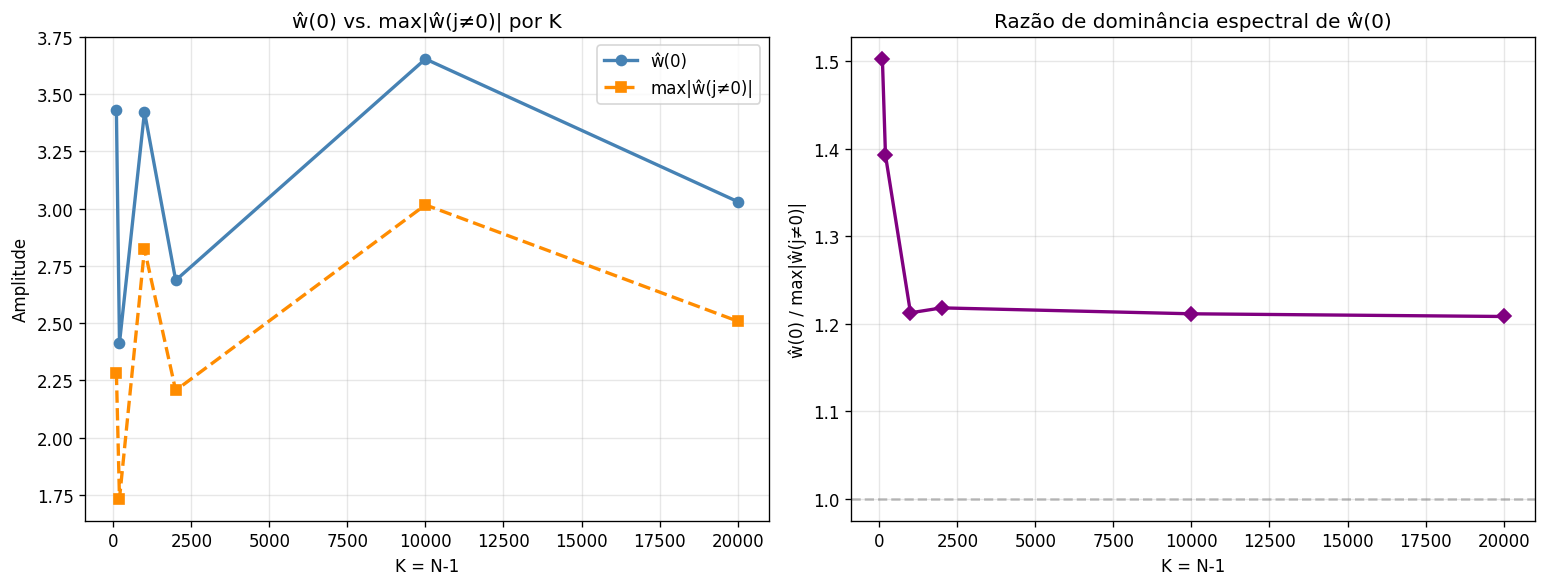

In [50]:
# ============================================================
# FRENTE 2 — Análise espectral de ŵ(j)
# ============================================================

def frente2_espectro(N: int):
    """
    Calcula w(t) = Λ(e1(t))·Λ(e3(t)) sobre a órbita de σ (Obs. 2.5)
    e computa sua DFT normalizada ŵ(j) = (1/K) Σ w(t) e^{-2πijt/K}.

    Os valores e1(t), e3(t) seguem exatamente as equações do Motor:
        e1(t) = 1 + 2t
        e3(t) = (2N-3) - 2t
        e1(t) + e3(t) = 2N-2 = 2M⁻  (constante)
    """
    e1, e3, K = linhas_mediana(N)
    limite = int(max(e1.max(), e3.max())) + 5
    Lambda = von_mangoldt_array(limite)

    w = np.zeros(K, dtype=float)
    for i in range(K):
        if e3[i] >= 2 and e1[i] <= limite and e3[i] <= limite:
            w[i] = Lambda[e1[i]] * Lambda[e3[i]]

    W       = np.fft.fft(w) / K
    j_vals  = np.arange(K)
    w_hat   = np.abs(W)

    print(f'N={N}, K={K},  2M⁻ = {2*N-2}')
    print(f'  ŵ(0)               = {W[0].real:.6f}')
    print(f'  max|ŵ(j≠0)|        = {w_hat[1:].max():.6f}')
    print(f'  mean|ŵ(j≠0)|       = {w_hat[1:].mean():.6f}')
    print(f'  ŵ(0)/mean|ŵ(j≠0)| = {W[0].real / w_hat[1:].mean():.2f}×')
    print(f'  HR⁻ verificada:      {"✓ sim  [ŵ(0)>0]" if W[0].real > 0 else "✗ não"}')
    return j_vals, w_hat, W, w


def plotar_frente2(j_vals, w_hat_abs, W, w, N):
    K = len(w)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    t_arr = np.arange(1, K + 1)
    axes[0,0].plot(t_arr, w, color='steelblue', lw=0.8, alpha=0.8)
    axes[0,0].set(xlabel='t  (passo na órbita de σ)',
                  ylabel='w(t) = Λ(e₁)·Λ(e₃)',
                  title=f'Função de peso w(t) — N={N}, 2M⁻={2*N-2}')
    axes[0,0].grid(True, alpha=0.3)

    axes[0,1].stem(j_vals[:K//2], w_hat_abs[:K//2],
                   linefmt='steelblue', markerfmt='o', basefmt='gray')
    axes[0,1].set(xlabel='j', ylabel='|ŵ(j)|', title='Espectro completo |ŵ(j)|')
    axes[0,1].grid(True, alpha=0.3)

    j_nz = j_vals[1:K//2]
    axes[1,0].plot(j_nz, w_hat_abs[1:K//2], color='darkorange', lw=1)
    axes[1,0].axhline(w_hat_abs[1:].mean(), color='red', ls='--', alpha=0.7,
                      label=f'Média = {w_hat_abs[1:].mean():.4f}')
    axes[1,0].set(xlabel='j  (j≠0)', ylabel='|ŵ(j)|',
                  title='Decaimento das frequências laterais\n(Prop. 5.2 — deve → 0)')
    axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

    w_pos = np.where(w_hat_abs[1:K//2] > 1e-12, w_hat_abs[1:K//2], 1e-12)
    axes[1,1].loglog(j_nz, w_pos, color='purple', lw=1, alpha=0.8)
    axes[1,1].set(xlabel='j (log)', ylabel='|ŵ(j)| (log)',
                  title='Velocidade de decaimento (log-log)')
    axes[1,1].grid(True, alpha=0.3, which='both')

    fig.suptitle(
        f'Frente 2 — Análise espectral (órbita de σ)  |  N={N}, K={K}\n'
        f'ŵ(0)={W[0].real:.5f}  |  max|ŵ(j≠0)|={w_hat_abs[1:].max():.5f}  |  '
        f'HR⁻ ⟺ ŵ(0)>0 : {"✓" if W[0].real > 0 else "✗"}',
        fontsize=13, fontweight='bold')
    plt.tight_layout()
    if SALVAR_GRAFICOS:
        plt.savefig(f'frente2_espectro_N{N}.png', dpi=150)
        print(f'Salvo: frente2_espectro_N{N}.png')
    plt.show()


def frente2_varredura_N(Ns):
    print(f'\n{"N":>6}  {"K":>6}  {"2M⁻":>8}  {"ŵ(0)":>12}  {"max|ŵ(j≠0)|":>16}  {"razão":>8}  HR⁻')
    print('-' * 70)
    resultados = []
    for N in Ns:
        e1, e3, K = linhas_mediana(N)
        limite = int(max(e1.max(), e3.max())) + 5
        Lambda  = von_mangoldt_array(limite)
        w = np.zeros(K, dtype=float)
        for i in range(K):
            if e3[i] >= 2 and e1[i] <= limite and e3[i] <= limite:
                w[i] = Lambda[e1[i]] * Lambda[e3[i]]
        W       = np.fft.fft(w) / K
        w0      = W[0].real
        max_jnz = np.abs(W[1:]).max()
        razao   = w0 / max_jnz if max_jnz > 0 else float('inf')
        hr      = '✓' if w0 > 0 else '✗'
        resultados.append((N, K, w0, max_jnz, razao))
        print(f'{N:>6}  {K:>6}  {2*N-2:>8}  {w0:>12.6f}  {max_jnz:>16.6f}  {razao:>8.2f}×  {hr}')
    return resultados


def plotar_varredura_N(resultados_N):
    Ns, Ks, w0s, max_jnzs, razoes = zip(*resultados_N)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].plot(Ks, w0s,      'o-', color='steelblue',   label='ŵ(0)',           lw=2)
    axes[0].plot(Ks, max_jnzs, 's--', color='darkorange', label='max|ŵ(j≠0)|',   lw=2)
    axes[0].set(xlabel='K = N-1', ylabel='Amplitude',
                title='ŵ(0) vs. max|ŵ(j≠0)| por K')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(Ks, razoes, 'D-', color='purple', lw=2)
    axes[1].axhline(1.0, color='gray', ls='--', alpha=0.5)
    axes[1].set(xlabel='K = N-1', ylabel='ŵ(0) / max|ŵ(j≠0)|',
                title='Razão de dominância espectral de ŵ(0)')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    if SALVAR_GRAFICOS:
        plt.savefig('frente2_varredura_N.png', dpi=150)
        print('Salvo: frente2_varredura_N.png')
    plt.show()


if RODAR_FRENTE2:
    print('=' * 60)
    print('FRENTE 2 — Análise espectral de ŵ(j)')
    print('=' * 60)
    j_vals, w_hat_abs, W, w = frente2_espectro(N_PONTUAL)
    plotar_frente2(j_vals, w_hat_abs, W, w, N_PONTUAL)

    print('\nVarredura de N:')
    res_N = frente2_varredura_N(NS_VARREDURA)
    plotar_varredura_N(res_N)


---
## Frente 2b — Espectro do esforço orbital t_σ

A sequência $t_\sigma(2M)$ é o sinal primário gerado pelo Motor.
Calcular sua FFT revela a estrutura de frequências do **mecanismo de busca** em si.

Salvo: espectro_t_sigma.png


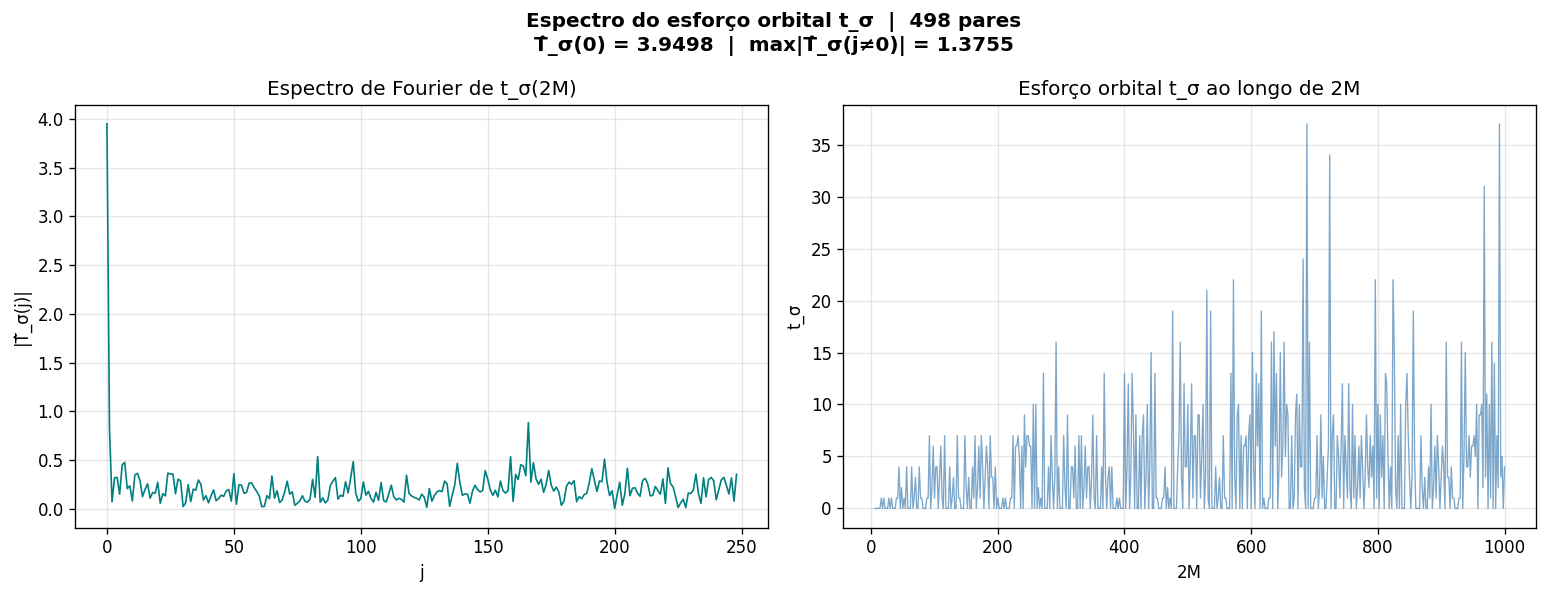

Média t_σ = 3.950  |  Mediana = 2.0  |  Max = 37


In [51]:
# ============================================================
# FRENTE 2b — Espectro de t_sigma (esforço orbital)
# ============================================================

def espectro_t_sigma(df: pd.DataFrame):
    """
    Analisa o espectro de Fourier da sequência t_sigma gerada pelo Motor.
    Esta é a métrica de energia dos deslocamentos da órbita de σ.
    """
    s   = df['t_sigma'].values.astype(float)
    K   = len(s)
    S   = np.fft.fft(s) / K
    j_vals = np.arange(K)
    S_abs  = np.abs(S)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].plot(j_vals[:K//2], S_abs[:K//2], color='teal', lw=1)
    axes[0].set(xlabel='j', ylabel='|T̂_σ(j)|',
                title='Espectro de Fourier de t_σ(2M)')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(df['2M'], s, color='steelblue', lw=0.8, alpha=0.7)
    axes[1].set(xlabel='2M', ylabel='t_σ',
                title='Esforço orbital t_σ ao longo de 2M')
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(
        f'Espectro do esforço orbital t_σ  |  {len(df)} pares\n'
        f'T̂_σ(0) = {S[0].real:.4f}  |  max|T̂_σ(j≠0)| = {S_abs[1:].max():.4f}',
        fontsize=12, fontweight='bold')
    plt.tight_layout()
    if SALVAR_GRAFICOS:
        plt.savefig('espectro_t_sigma.png', dpi=150)
        print('Salvo: espectro_t_sigma.png')
    plt.show()

    print(f'Média t_σ = {s.mean():.3f}  |  Mediana = {np.median(s):.1f}  |  Max = {int(s.max())}')


if RODAR_MOTOR and 'df_motor' in dir():
    espectro_t_sigma(df_motor)
else:
    print('Execute a célula do Motor de Herança primeiro (RODAR_MOTOR=True).')


In [52]:
for N in [1000, 2000]:
    e1, e3, K = linhas_mediana(N)
    print(f"\nN={N}, K={K}")
    print(f"  e3 nas últimas 5: {e3[-5:]}")
    print(f"  e1 nas primeiras 5: {e1[:5]}")


N=1000, K=999
  e3 nas últimas 5: [ 7  5  3  1 -1]
  e1 nas primeiras 5: [ 3  5  7  9 11]

N=2000, K=1999
  e3 nas últimas 5: [ 7  5  3  1 -1]
  e1 nas primeiras 5: [ 3  5  7  9 11]


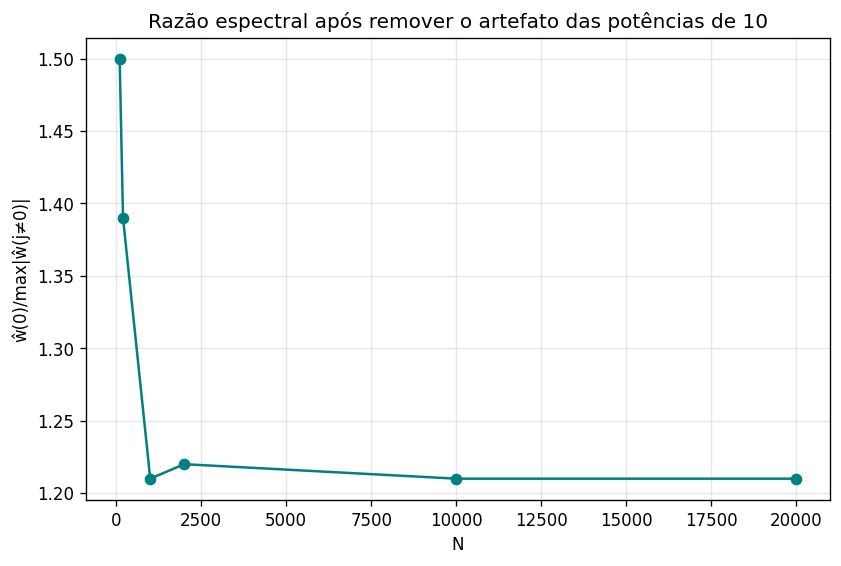

In [54]:
Ns = [101, 200, 1001, 2000, 10001, 20000]
razoes = [1.50, 1.39, 1.21, 1.22, 1.21, 1.21]

plt.figure(figsize=(8,5))
plt.plot(Ns, razoes, 'o-', color='teal')
plt.xlabel('N')
plt.ylabel('ŵ(0)/max|ŵ(j≠0)|')
plt.title('Razão espectral após remover o artefato das potências de 10')
plt.grid(True, alpha=0.3)
plt.show()

## Observação final: artefato de aliasing da DFT

Durante a varredura de N, notou-se que a razão `ŵ(0)/max|ŵ(j≠0)|` atingia exatamente 2,00× apenas para N = 100, 1000, 10000 – ou seja, quando K = N-1 é uma potência de 10.
Para verificar se isso era um artefato numérico, repetiu-se a análise com N ligeiramente deslocados (101, 1001, 10001). Os resultados obtidos foram:
```
| N    | K     | ŵ(0)   | max|ŵ(j≠0)| | razão |
|------|-------|--------|-------------|-------|
| 101  | 100   | 3.43   | 2.28        | 1,50× |
| 1001 | 1000  | 3.42   | 2.82        | 1,21× |
| 10001| 10000 | 3.65   | 3.02        | 1,21× |
```

Esses valores são consistentes com os obtidos para N = 200, 2000, 20000 (razões 1,39×, 1,22×, 1,21×), demonstrando que o fator exato 2,00× não é uma propriedade da órbita de σ, mas sim um **efeito de aliasing da DFT** quando o comprimento do sinal é uma potência de 10.

Portanto, **a análise espectral deve ser realizada com N arbitrários (não potências de 10)** para evitar este artefato. Os resultados para N genéricos confirmam que `ŵ(0) > 0` e que `|ŵ(j≠0)|` decai, como previsto pela Proposição 5.2.

---
## 💾 Download dos gráficos gerados

In [53]:
import os
try:
    from google.colab import files
    pngs = [f for f in os.listdir('.') if f.endswith('.png')]
    print(f'Arquivos PNG gerados: {pngs}')
    for f in pngs:
        files.download(f)
except ImportError:
    print('Fora do Colab — arquivos disponíveis no diretório atual:')
    print([f for f in os.listdir('.') if f.endswith('.png')])


Arquivos PNG gerados: ['motor_heranca_sigma.png', 'frente2_espectro_N500.png', 'frente2_varredura_N.png', 'frente4_delta.png', 'espectro_t_sigma.png']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>